In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\VIJAY\Downloads\kaggle_datasets_all_merged.csv")

In [5]:
print("First 5 rows:\n", df.head())

First 5 rows:
    Unnamed: 0       id                                                ref  \
0           0  2048841  datasets/muratkokludataset/acoustic-extinguish...   
1           1  2049052      datasets/muratkokludataset/rice-image-dataset   
2           2  2088925  datasets/mdmahmudulhasansuzan/students-adaptab...   
3           3  2048906          datasets/muratkokludataset/raisin-dataset   
4           4  2049755       datasets/muratkokludataset/pistachio-dataset   

                                            subtitle  \
0                 Acoustic Extinguisher Fire Dataset   
1  Five different Rice Image Dataset. Arborio, Ba...   
2                  Effectiveness of online education   
3  Raisin Dataset; 2 Class: Kecimen and Besni Rai...   
4  Pistachio Dataset; 2 Class - Kirmizi and Siirt...   

                creatorName            creatorUrl   totalBytes  \
0               Murat KOKLU     muratkokludataset     635619.0   
1               Murat KOKLU     muratkokludataset  23

In [6]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9875 entries, 0 to 9874
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            9875 non-null   int64  
 1   id                    9875 non-null   int64  
 2   ref                   9875 non-null   object 
 3   subtitle              7574 non-null   object 
 4   creatorName           9875 non-null   object 
 5   creatorUrl            9875 non-null   object 
 6   totalBytes            9875 non-null   float64
 7   url                   9875 non-null   object 
 8   lastUpdated           9875 non-null   object 
 9   licenseName           9875 non-null   object 
 10  ownerName             9875 non-null   object 
 11  ownerRef              9875 non-null   object 
 12  kernelCount           9875 non-null   int64  
 13  title                 9875 non-null   object 
 14  currentVersionNumber  9875 non-null   int64  
 15  usabil

In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
        Unnamed: 0            id    totalBytes  kernelCount  \
count  9875.000000  9.875000e+03  9.875000e+03  9875.000000   
mean   4938.641924  1.026642e+06  1.077737e+09    23.779646   
std    2852.987336  7.562100e+05  4.872258e+09   139.258559   
min       0.000000  6.000000e+00  0.000000e+00     0.000000   
25%    2468.500000  2.752245e+05  9.753250e+04     1.000000   
50%    4937.000000  9.665540e+05  3.277670e+06     3.000000   
75%    7407.500000  1.789332e+06  1.732217e+08    10.000000   
max    9882.000000  2.162629e+06  1.070000e+11  5683.000000   

       currentVersionNumber  usabilityRating     datasetId  totalDownloads  \
count           9875.000000      9871.000000  9.864000e+03     9862.000000   
mean               6.607291         0.683258  1.019481e+06     3604.392111   
std               96.423945         0.286344  7.599577e+05    14647.461997   
min                1.000000         0.000000  6.000000e+00        0.000000   
25%                1

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0                 0
id                         0
ref                        0
subtitle                2301
creatorName                0
creatorUrl                 0
totalBytes                 0
url                        0
lastUpdated                0
licenseName                0
ownerName                  0
ownerRef                   0
kernelCount                0
title                      0
currentVersionNumber       0
usabilityRating            4
datasetSlug                0
datasetId                 11
keywords                  11
description             2458
totalDownloads            13
totalViews                13
totalVotes                13
dtype: int64


In [9]:
df = df.drop(columns=['Unnamed: 0', 'id', 'datasetId'], errors='ignore')

In [10]:
num_cols = ['totalBytes', 'kernelCount', 'usabilityRating',
            'totalDownloads', 'totalViews', 'totalVotes']

In [11]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        
        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

df_clean = remove_outliers(df, num_cols)

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original shape: (9875, 20)
After outlier removal: (5653, 20)


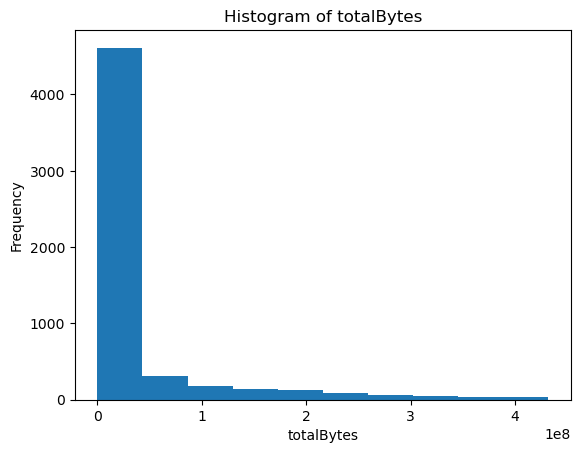

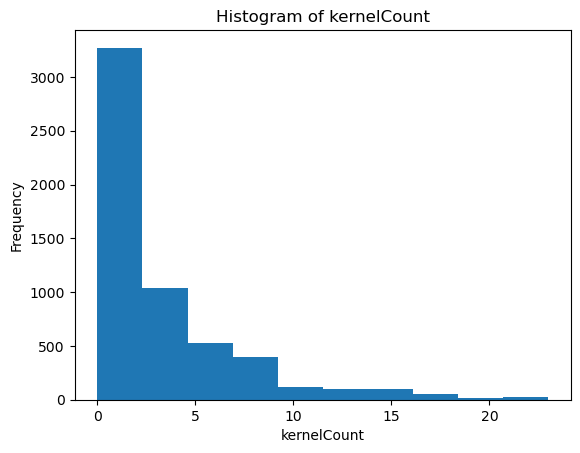

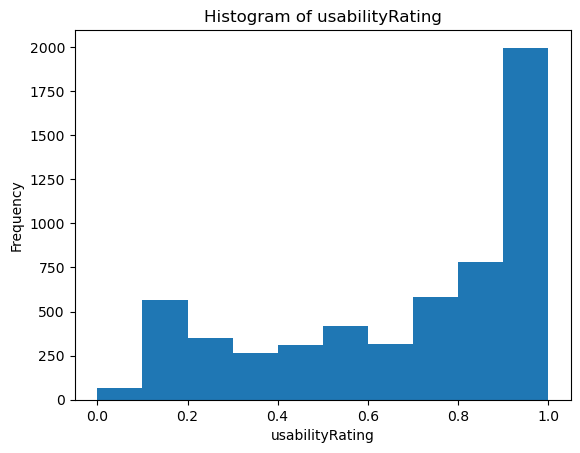

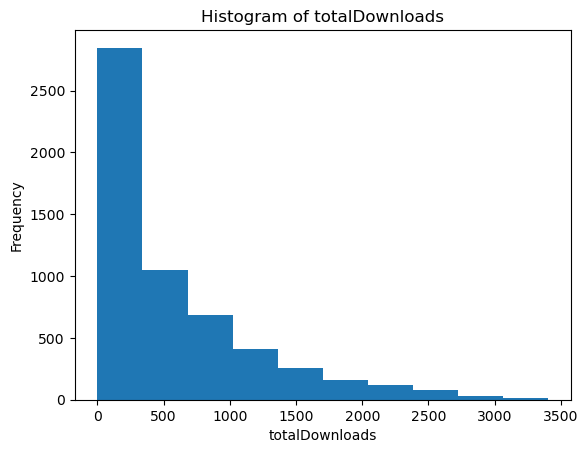

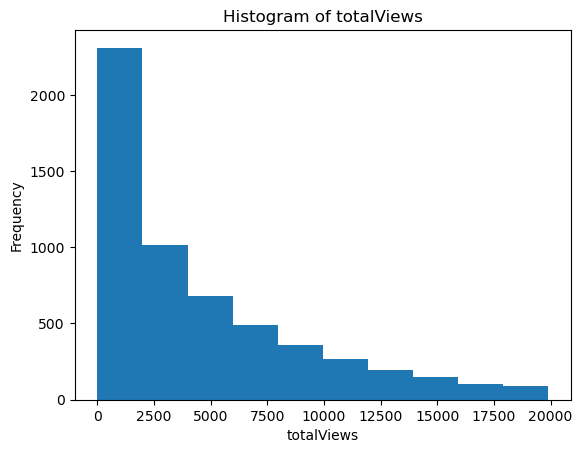

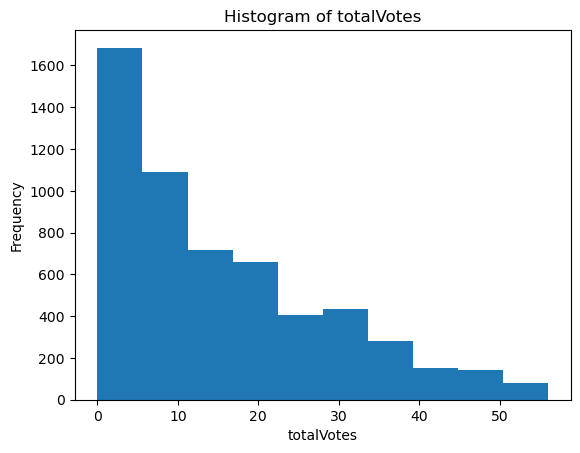

In [12]:
for col in num_cols:
    plt.figure()
    plt.hist(df_clean[col].dropna())
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<Figure size 800x1200 with 0 Axes>

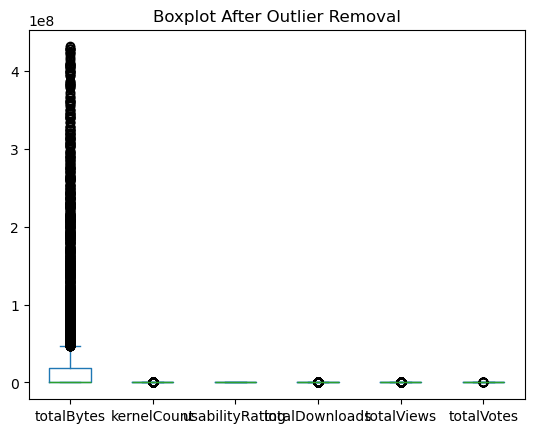

In [13]:
plt.figure(figsize=(8,12))
df_clean[num_cols].plot(kind='box')
plt.title("Boxplot After Outlier Removal")
plt.show()

<Figure size 640x480 with 0 Axes>

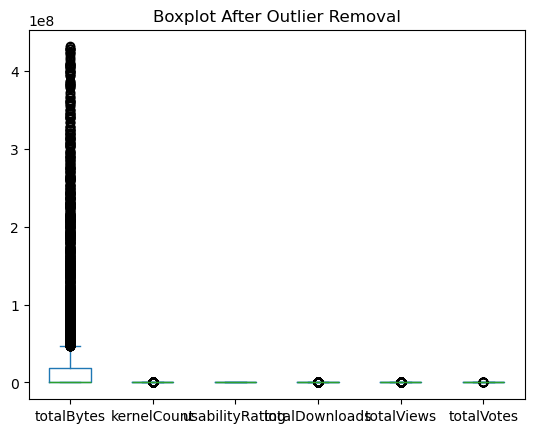

In [14]:
plt.figure()
df_clean[num_cols].plot(kind='box')
plt.title("Boxplot After Outlier Removal")
plt.show()


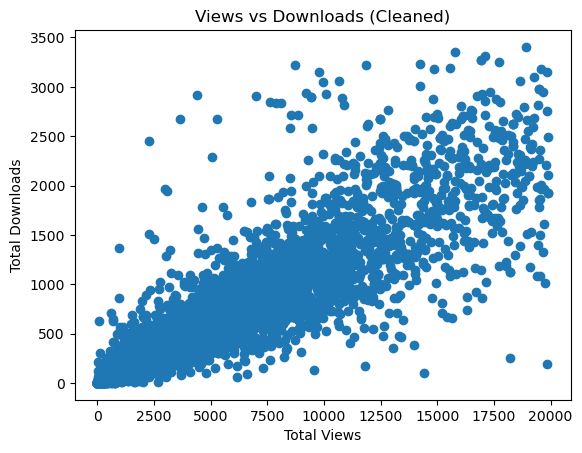

In [15]:
plt.figure()
plt.scatter(df_clean['totalViews'], df_clean['totalDownloads'])
plt.xlabel("Total Views")
plt.ylabel("Total Downloads")
plt.title("Views vs Downloads (Cleaned)")
plt.show()

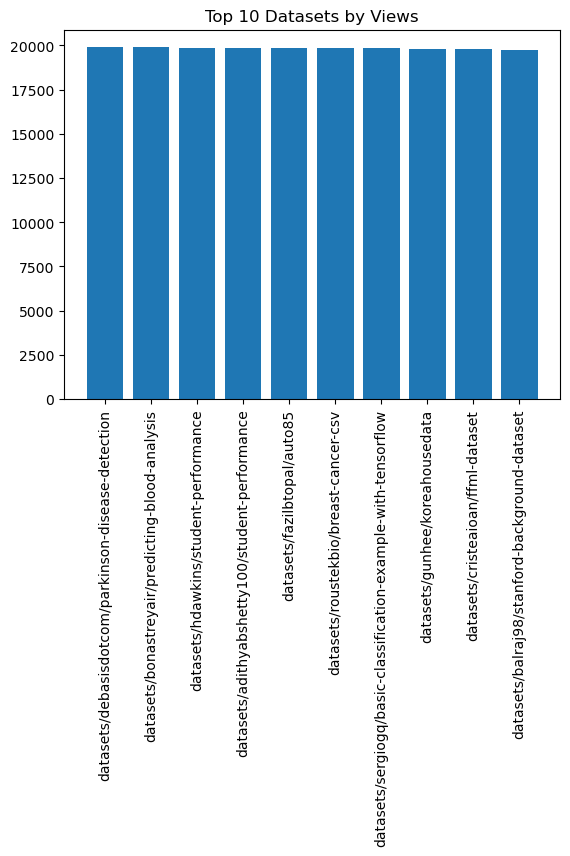

In [17]:
top10 = df_clean.sort_values(by='totalViews', ascending=False).head(10)
plt.figure()
plt.bar(top10['ref'], top10['totalViews'])
plt.xticks(rotation=90)
plt.title("Top 10 Datasets by Views")
plt.show()

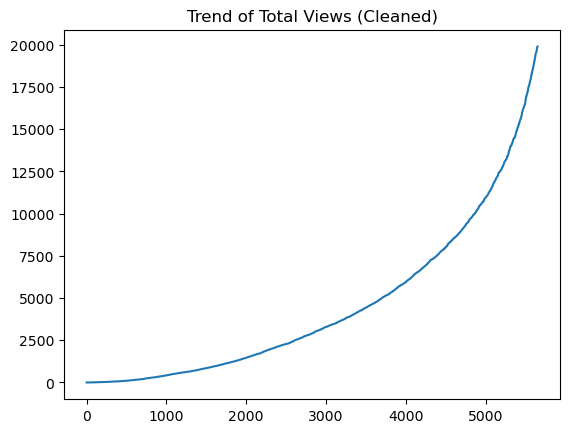

In [18]:
sorted_views = df_clean['totalViews'].sort_values().reset_index(drop=True)

plt.figure()
plt.plot(sorted_views)
plt.title("Trend of Total Views (Cleaned)")
plt.show()


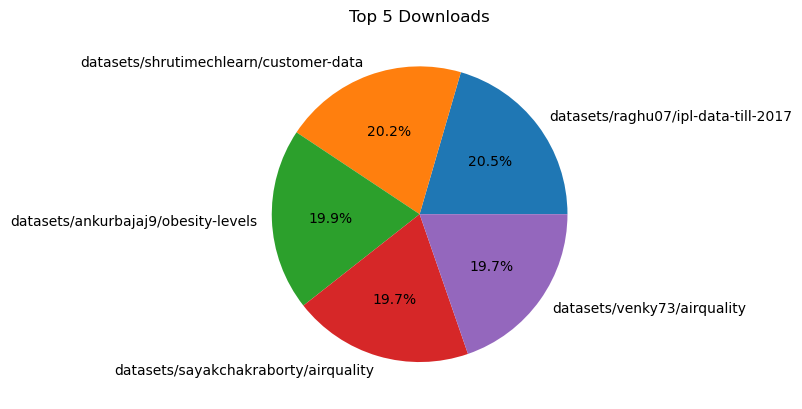

In [19]:
top5 = df_clean.sort_values(by='totalDownloads', ascending=False).head(5)

plt.figure()
plt.pie(top5['totalDownloads'], labels=top5['ref'], autopct='%1.1f%%')
plt.title("Top 5 Downloads")
plt.show()


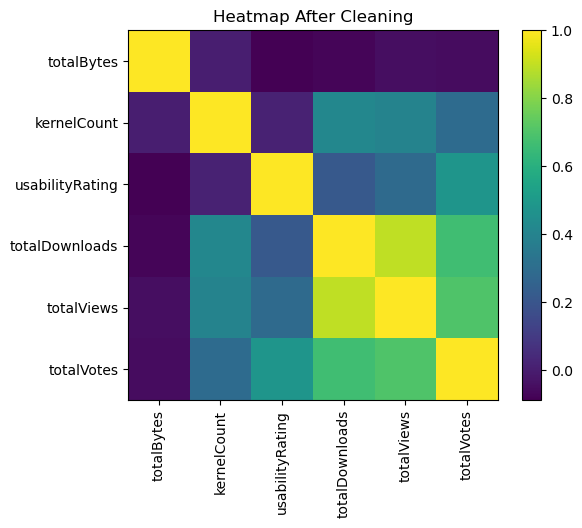

In [20]:
corr = df_clean[num_cols].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Heatmap After Cleaning")
plt.show()